In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [98]:
df=pd.read_excel("D:/AK_Project/swiggy_data.xlsx")
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [3]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [5]:
df.isna().sum()

State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

In [6]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [7]:
df.shape

(197430, 10)

In [8]:
df.shape[0]

197430

In [9]:
df.shape[1]

10

In [10]:
# Total Sales
print("Total Sales :",round(df['Price (INR)'].sum(),2))

Total Sales : 53012505.77


In [11]:
# Average Rating – Customer satisfaction level across all restaurants.
print("Average Rating : ",round(df['Rating'].mean(),2))

Average Rating :  4.34


In [12]:
# Average Order Value (₹) – Revenue per order.
print("Average Order values : ",round(df['Price (INR)'].mean(),2))

Average Order values :  268.51


In [13]:
# Ratings Count – Total number of cusomer reviews.
print("Rating Count :",df['Rating Count'].sum())

Rating Count : 5591574


In [14]:
# Total Orders – Number of food orders received.
print("order received :",df['Order Date'].count())
print("order received :",len(df))

order received : 197430
order received : 197430


In [15]:
# Monthly Sales Trend – Shows how total sales fluctuate month by month.
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [16]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [22]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YEAR_MONTH'] = df['Order Date'].dt.to_period("M").astype(str)

In [23]:
monthwise = df.groupby('YEAR_MONTH')['Price (INR)'].sum().reset_index()

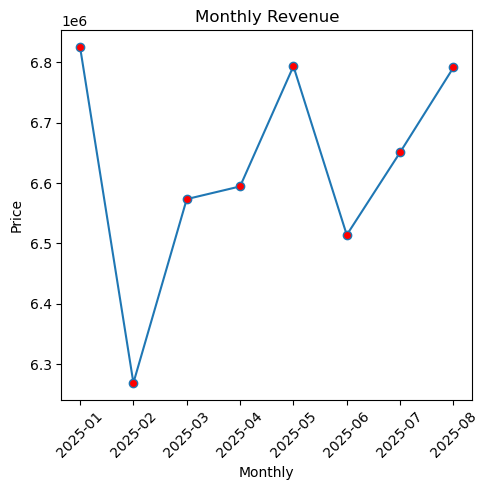

In [34]:
plt.figure(figsize=(5,5))
plt.plot(monthwise['YEAR_MONTH'],monthwise['Price (INR)'],marker="o",markerfacecolor="red")
plt.title("Monthly Revenue")
plt.xlabel("Monthly")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Daily Sales Trend – Highlights order and revenue variations across days of the week.
df['Order_Day'] = pd.to_datetime(df['Order Date']).dt.day_name()

In [52]:
daily_revenue = df.groupby('Order_Day')['Price (INR)'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

In [53]:
print(daily_revenue)

Order_Day
Monday       7445437.01
Tuesday      7359414.01
Wednesday    7542103.06
Thursday     7664619.49
Friday       7579992.78
Saturday     7782935.40
Sunday       7638004.02
Name: Price (INR), dtype: float64


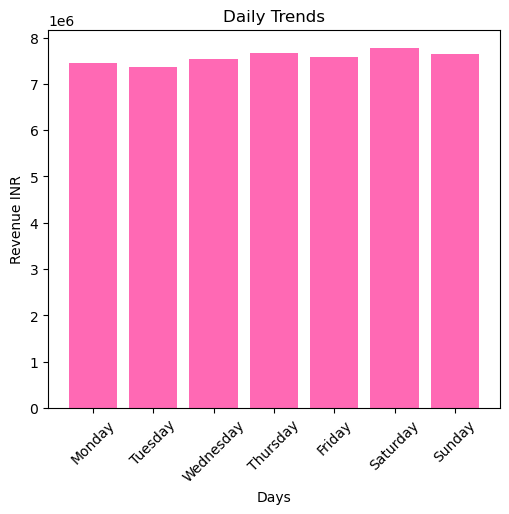

In [59]:
plt.figure(figsize=(5,5))
plt.bar(daily_revenue.index,daily_revenue.values,color="hotpink")
plt.xticks(rotation=45)
plt.tight_layout()
plt.title("Daily Trends")
plt.xlabel('Days')
plt.ylabel('Revenue INR')
plt.show()

In [60]:
# Total Sales by Food Type (Veg vs Non-Veg) – Compares revenue contribution by cuisine type.

In [67]:
non_veg_dish=['chicken','egg','fish','mutton','prawn','biryani','kabab','kebab','non-veg','non veg']
df['dish_distribution'] = np.where(
    df['Dish Name'].str.lower().str.contains("|".join(non_veg_dish),na=False),
    "Non-Veg",
    "Veg"
)

In [68]:
df[['Dish Name','dish_distribution']]

,Dish Name,dish_distribution
0,Butter Murukku-200gm,Veg
1,Badam Milk,Veg
2,Chow Chow Bath,Veg
3,Kesari Bath,Veg
4,Mix Raitha,Veg
...,...,...
197425,Soya cheese chilli momo ...,Veg
197426,Kurkure momo fried ...,Veg
197427,Chilli cheese momo,Veg
197428,Veg Momos (8 Pc),Veg


In [69]:
food_revenue = df.groupby('dish_distribution')['Price (INR)'].sum().reset_index()

In [70]:
food_revenue

,dish_distribution,Price (INR)
0,Non-Veg,19684002.06
1,Veg,33328503.71


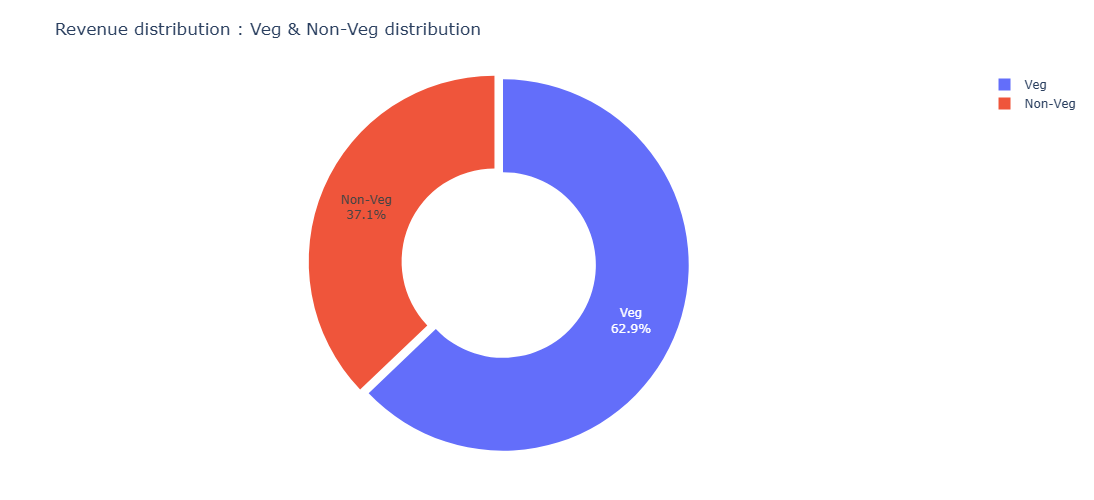

In [95]:
fig = px.pie(
    food_revenue,
    values='Price (INR)',
    names = 'dish_distribution',
    hole = 0.5,
    title = "Revenue distribution : Veg & Non-Veg distribution",
)
fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0]
)
fig.update_layout(
    height=500,
    margin=dict(t=70,b=40,l=40,r=60)
)
fig.show()

In [96]:
# Total Sales by State (Map Visualization) – Displays state-wise revenue distribution.

In [119]:
total_state_revenue = df.groupby('State')['Price (INR)'].sum().sort_values(ascending=False)

In [120]:
total_state_revenue

State
Karnataka            5456798.41
Uttar Pradesh        3117359.65
Telangana            3021711.62
Maharashtra          3015573.35
Delhi                2829180.60
Gujarat              2817836.02
Punjab               2809440.69
West Bengal          2662801.76
Tamil Nadu           2642594.63
Rajasthan            2502932.61
Madhya Pradesh       1970100.77
Goa                  1539479.41
Haryana              1438455.54
Meghalaya            1427851.75
Himachal Pradesh     1382689.18
Jammu and Kashmir    1322513.82
Uttarakhand          1301699.70
Kerala               1283926.46
Assam                1259012.24
Manipur              1254429.93
Bihar                1231696.87
Chhattisgarh         1226832.20
Jharkhand            1197037.32
Odisha               1193584.77
Tripura              1144272.46
Mizoram               824930.99
Nagaland              576797.60
Sikkim                560965.42
Name: Price (INR), dtype: float64

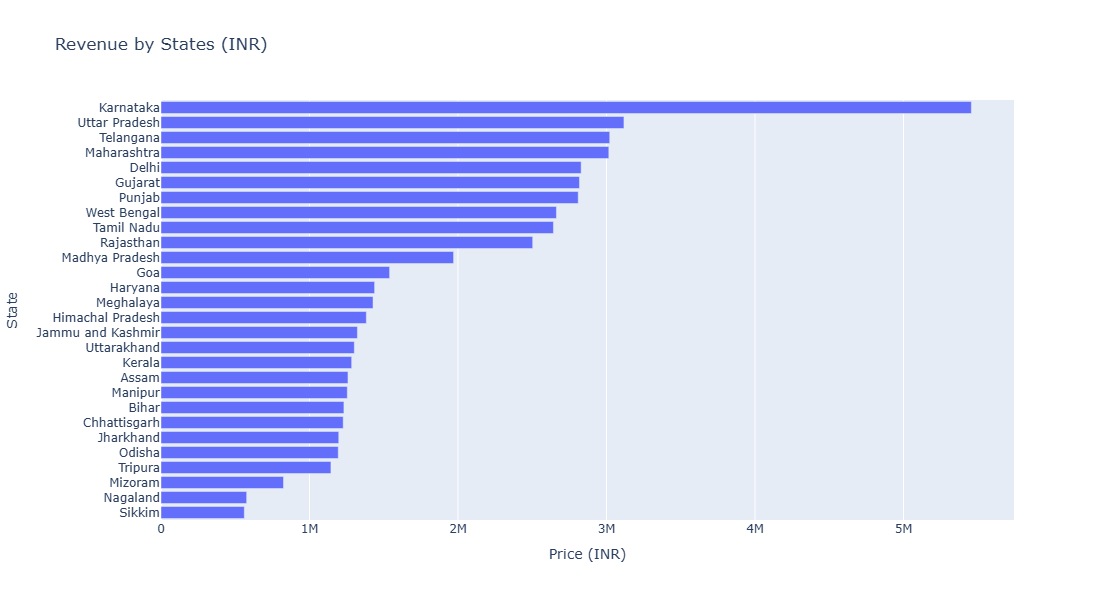

In [127]:
fig = px.bar(
    total_state_revenue,
    x="Price (INR)",
    y=total_state_revenue.index,
    orientation = "h",
    title = "Revenue by States (INR)"
)
fig.update_layout(height=600,yaxis=dict(autorange="reversed"))
fig.show()

In [129]:
# Quarterly Performance Summary – Combines Sales, Ratings, and Orders by Quarter.
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Quaterly'] = df['Order Date'].dt.to_period("Q").astype(str)

In [130]:
df[['Order Date','Quaterly']].head()

,Order Date,Quaterly
0,2025-06-29,2025Q2
1,2025-04-03,2025Q2
2,2025-01-15,2025Q1
3,2025-04-17,2025Q2
4,2025-03-13,2025Q1


In [142]:
quaterly_summary = df.groupby('Quaterly').agg(
    total_sales = ("Price (INR)","sum"),
    Avg_Rating = ("Rating","mean"),
    order_count = ("Order Date","count")
).sort_values("Quaterly")

quaterly_summary['total_sales'] = quaterly_summary['total_sales'].round(0)
quaterly_summary['Avg_Rating'] = quaterly_summary['Avg_Rating'].round(2)

In [144]:
quaterly_summary

,total_sales,Avg_Rating,order_count
Quaterly,,,
2025Q1,19667822.0,4.34,73096
2025Q2,19902257.0,4.34,74163
2025Q3,13442427.0,4.34,50171


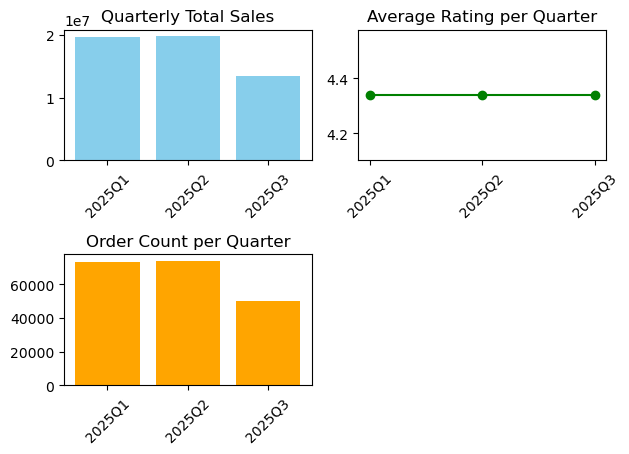

In [152]:
# 1. Total Sales
plt.subplot(2,2,1)
plt.bar(quaterly_summary.index, quaterly_summary['total_sales'], color='skyblue')
plt.title("Quarterly Total Sales")
plt.xticks(rotation=45)

# 2. Average Rating
plt.subplot(2,2,2)
plt.plot(quaterly_summary.index, quaterly_summary['Avg_Rating'], marker='o', color='green')
plt.title("Average Rating per Quarter")
plt.xticks(rotation=45)

# 3. Order Count
plt.subplot(2,2,3)
plt.bar(quaterly_summary.index, quaterly_summary['order_count'], color='orange')
plt.title("Order Count per Quarter")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [159]:
# Top 5 Cities by Sales – Identifies leading cities contributing the most revenue.
top_5_city = df.groupby('City')['Price (INR)'].sum().sort_values(ascending=False).head()

In [160]:
top_5_city

City
Bengaluru    5456798.41
Lucknow      3117359.65
Hyderabad    3021711.62
Mumbai       3015573.35
New Delhi    2829180.60
Name: Price (INR), dtype: float64

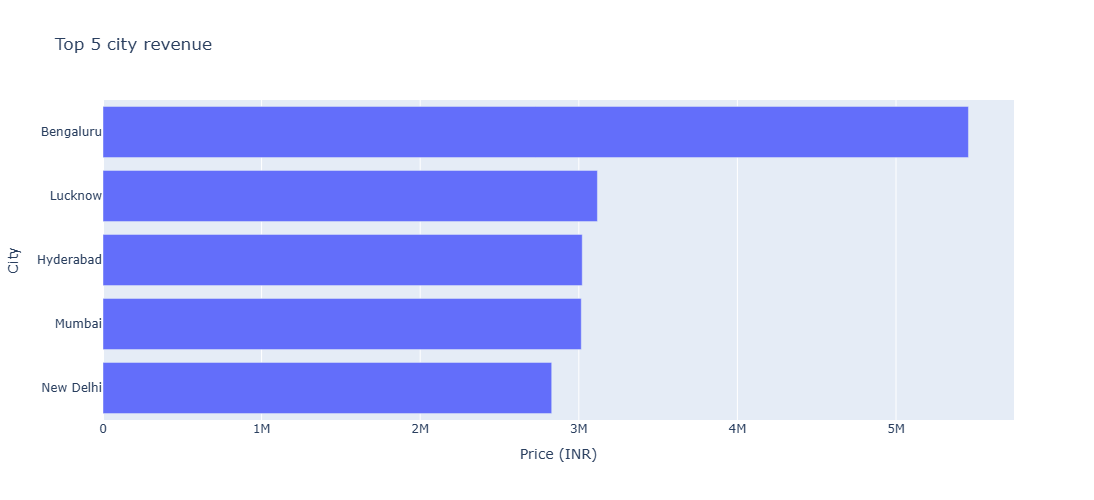

In [164]:
fig = px.bar(
    top_5_city,
    x="Price (INR)",
    y=top_5_city.index,
    orientation = "h",
    title = "Top 5 city revenue"
)
fig.update_layout(height=500,yaxis=dict(autorange="reversed"))
fig.show()

In [165]:
# Weekly Trend Analysis – Monitors weekly fluctuations in sales to identify consistency or peak periods.
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Weekly'] = df['Order Date'].dt.to_period('W').astype(str)

In [173]:
weekly_sales = df.groupby('Weekly')['Price (INR)'].sum().sort_values(ascending=False).reset_index()

In [174]:
weekly_sales

,Weekly,Price (INR)
0,2025-02-17/2025-02-23,1697992.73
1,2025-05-19/2025-05-25,1563458.34
2,2025-02-10/2025-02-16,1560241.45
3,2025-08-04/2025-08-10,1558098.72
4,2025-04-07/2025-04-13,1551114.39
5,2025-01-27/2025-02-02,1549636.81
6,2025-08-18/2025-08-24,1548112.71
7,2025-06-16/2025-06-22,1545937.96
8,2025-04-14/2025-04-20,1544439.18
9,2025-01-06/2025-01-12,1543434.40


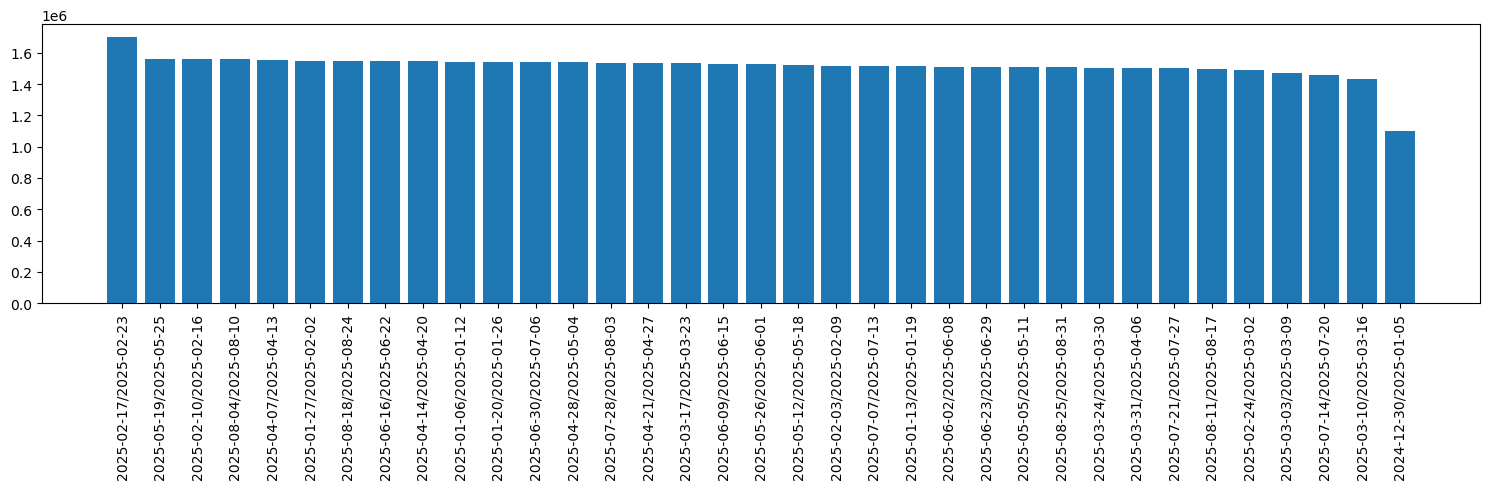

In [183]:
plt.figure(figsize=(15,5))
plt.bar(weekly_sales['Weekly'],weekly_sales['Price (INR)'])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

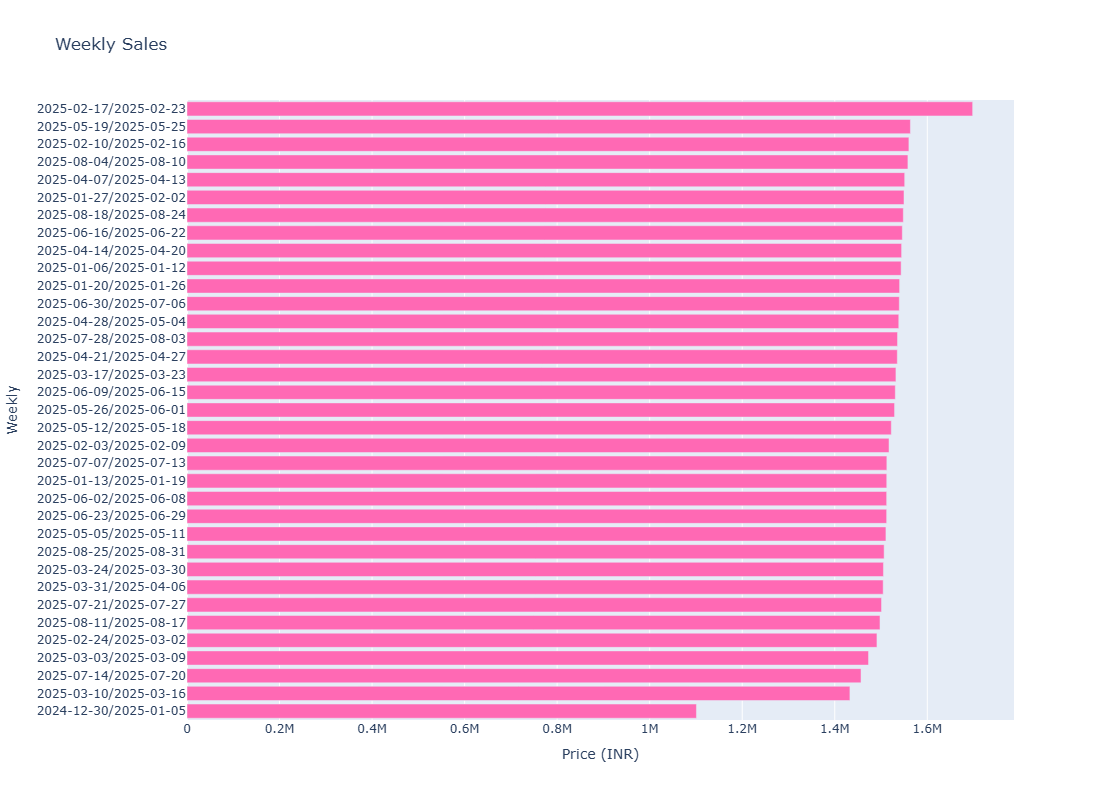

In [188]:
fig = px.bar(
    weekly_sales,
    x='Price (INR)',
    y='Weekly',
    orientation="h",
    color_discrete_sequence=['hotpink'],
    title="Weekly Sales"
)
fig.update_layout(height=800,yaxis=dict(autorange="reversed"))
fig.show()